## **Problème :**

**1) Un étudiant ennuyé fait un avion en papier il s'amuse a lancer cette avion depuis la fenêtre de sa salle de cour un jour de vent. Il essaie d'étudier la hauteur de l'avion en fonction du temps, au cour de son lancer il recueil la hauteur de l'avion toute les 0.5 secondes. Malheuresement il n'écris pas assez vite et n'arrive pas a noté tout les points il a des troucs dans ces notes. Voici les échantillons de données qu'il récupère :**  

* Echantillon 1 :   

| X | 0.5 | 1 | 1.5 | 2 | 2.5 |
| -------- | -------- | -------- | -------- | -------- | -------- |
| y(x)    | 20,293     |   38,481   | 53,559     | 64,713     |  75,673    |

* Echantillon 2 : 

| X | 3.5 | 4 | 4.5 | 5 | 5.5 |
| -------- | -------- | -------- | -------- | -------- | -------- |
| y(x)    | 88,510     | 91,412     | 93,112     | 89,968     | 84,703     |

* Echantillon 3 : 

| X | 6.5 | 7 | 7.5 | 8 | 8.5 |
| -------- | -------- | -------- | -------- | -------- | -------- |
| y(x)    | 68,320     | 56,517     | 42,888     | 27,361     | 7,254     |

a. Réaliser une interpolation de la fonction représentant la courbe de l'avion sur le premier échantillon. Vous utiliserez la méthode de Newton en calculant dans un premier temp la pente déscendante du tableau des différence divisé. Puis vous représenterez le polynome P1 sous la forme $P1[0]=[x_0,\dots, x_n]$ avec les x étant les points de support et $P1[1]=[a_0, \dots, a_n]$ avec a représentant les coefficients respectif.

In [65]:
import math
import numpy as np
import matplotlib.pyplot as plt

#---------- Echantillon 1 :
X1 = [0.5, 1.0, 1.5, 2.0, 2.5]                  # Points de support
Y1 = [20.293, 38.481, 53.559, 64.713, 75.673]   # Valeurs correspondantes aux points de support sur la fonction inconnue à interpoler


def Tab_diff_div_vect(X, Y):
    """
    Calcule le tableau de différences divisées et retourne seulement le vecteur de la pente descendante

    Paramètres
    ----------
    X : list
        Liste des points de support
    Y : list
        Liste des valeurs correspondantes aux points de support sur la fonction à interpoler

    Retourne
    -------
    vect : list
        Vecteur de la pente descendante
    """
    vect = [0 for i in range(len(X))] # On initialise le vecteur de la pente descendante
    for i in range(0, len(X)): # On initialise la première colonne du tableau
        vect[i] = Y[i] # On met les valeurs de Y dans la première colonne

    for i in range(1, len(X)): # On remplit le tableau
        for j in range(len(X)-1, i-1, -1): # On remplit le vecteur de la pente descendante
            vect[j] = (vect[j] - vect[j-1]) / (X[j] - X[j-i]) # On remplit la case avec la formule des différences divisées
    
    return vect # On retourne le vecteur de la pente descendante

def InterpolationNewton(X, Coef):
    """
    Interpole la fonction inconnue à partir des points de support et des coefficients de la pente descendante

    Paramètres
    ----------
    X : list
        Liste des points de support
    Coef : list
        Liste des coefficients de la pente descendante

    Retourne
    -------
    P : list
        Tableau P qui représente le polynôme d'interpolation du support X sous la forme [[X], [Coef]]
    """
    n = len(X) - 1 # On récupère le degré du polynôme
    P = [[0] * (n+1) for _ in range(2)] # On initialise le tableau P
    P[0] = X # On met les points de support dans la première ligne du tableau P
    P[1] = Coef # On met les coefficients de la pente descendante dans la deuxième ligne du tableau P

    return P # On retourne le tableau P qui représente le polynôme d'interpolation du support X

Coef = Tab_diff_div_vect(X1, Y1) # On calcule le vecteur de la pente descendante 
P1 = InterpolationNewton(X1, Coef) # On calcule le polynôme d'interpolation
print("-------------------------- Echantillon 1 --------------------------")
print("Points de support : ", X1) # On affiche les points de support
print("Valeurs correspondantes aux points de support : ", Y1) # On affiche les valeurs correspondantes aux points de support
print("Vecteur de la pente descendante : ", Coef) # On affiche le vecteur de la pente descendante
print("Polynôme d'interpolation de Newton : ", P1) # On affiche le polynôme d'interpolation
print("------------------------------------------------------------------\n")

-------------------------- Echantillon 1 --------------------------
Points de support :  [0.5, 1.0, 1.5, 2.0, 2.5]
Valeurs correspondantes aux points de support :  [20.293, 38.481, 53.559, 64.713, 75.673]
Vecteur de la pente descendante :  [20.293, 36.376000000000005, -6.220000000000013, -1.085333333333324, 3.029333333333336]
Polynôme d'interpolation de Newton :  [[0.5, 1.0, 1.5, 2.0, 2.5], [20.293, 36.376000000000005, -6.220000000000013, -1.085333333333324, 3.029333333333336]]
------------------------------------------------------------------



b. Réaliser une interpolation de la fonction représentant la courbe de l'avion sur le deuxième échantillon. 

In [66]:
#---------- Echantillon 2 :
X2 = [3.5, 4.0, 4.5, 5.0, 5.5]                  # Points de support
Y2 = [88.510, 91.412, 93.112, 89.968, 84.703]   # Valeurs correspondantes aux points de support sur la fonction inconnue à interpoler

Coef = Tab_diff_div_vect(X2, Y2) # On calcule le vecteur de la pente descendante
P2 = InterpolationNewton(X2, Coef) # On calcule le polynôme d'interpolation
print("-------------------------- Echantillon 2 --------------------------")
print("Points de support : ", X2) # On affiche les points de support
print("Valeurs correspondantes aux points de support : ", Y2) # On affiche les valeurs correspondantes aux points de support
print("Vecteur de la pente descendante : ", Coef) # On affiche le vecteur de la pente descendante
print("Polynôme d'interpolation de Newton : ", P2) # On affiche le polynôme d'interpolation
print("------------------------------------------------------------------\n")

-------------------------- Echantillon 2 --------------------------
Points de support :  [3.5, 4.0, 4.5, 5.0, 5.5]
Valeurs correspondantes aux points de support :  [88.51, 91.412, 93.112, 89.968, 84.703]
Vecteur de la pente descendante :  [88.51, 5.804000000000002, -2.404000000000025, -4.855999999999956, 4.243333333333291]
Polynôme d'interpolation de Newton :  [[3.5, 4.0, 4.5, 5.0, 5.5], [88.51, 5.804000000000002, -2.404000000000025, -4.855999999999956, 4.243333333333291]]
------------------------------------------------------------------



c. Réaliser une interpolation de la fonction représentant la courbe de l'avion sur le troisième échantillon  

In [67]:
#---------- Echantillon 3 :
X3 = [6.5, 7.0, 7.5, 8.0, 8.5]                  # Points de support
Y3 = [68.320, 56.517, 42.888, 27.361, 7.254]   # Valeurs correspondantes aux points de support sur la fonction inconnue à interpoler

Coef = Tab_diff_div_vect(X3, Y3) # On calcule le vecteur de la pente descendante
P3 = InterpolationNewton(X3, Coef) # On calcule le polynôme d'interpolation
print("-------------------------- Echantillon 3 --------------------------")
print("Points de support : ", X3) # On affiche les points de support
print("Valeurs correspondantes aux points de support : ", Y3) # On affiche les valeurs correspondantes aux points de support
print("Vecteur de la pente descendante : ", Coef) # On affiche le vecteur de la pente descendante
print("Polynôme d'interpolation de Newton : ", P3) # On affiche le polynôme d'interpolation
print("------------------------------------------------------------------\n")

-------------------------- Echantillon 3 --------------------------
Points de support :  [6.5, 7.0, 7.5, 8.0, 8.5]
Valeurs correspondantes aux points de support :  [68.32, 56.517, 42.888, 27.361, 7.254]
Vecteur de la pente descendante :  [68.32, -23.60599999999998, -3.6520000000000294, -0.09599999999997048, -1.740000000000021]
Polynôme d'interpolation de Newton :  [[6.5, 7.0, 7.5, 8.0, 8.5], [68.32, -23.60599999999998, -3.6520000000000294, -0.09599999999997048, -1.740000000000021]]
------------------------------------------------------------------



d. Utiliser maintenant tout les échantillons pour interpoler la fonction représentant la courbe de l'avion.

In [68]:
#---------- Tout les échantillons :
X4 = X1 + X2 + X3 # On concatène les points de support
Y4 = Y1 + Y2 + Y3 # On concatène les valeurs correspondantes aux points de support

Coef = Tab_diff_div_vect(X4, Y4) # On calcule le vecteur de la pente descendante
P4 = InterpolationNewton(X4, Coef) # On calcule le polynôme d'interpolation
print("-------------------------- Tout les échantillons --------------------------")
print("Points de support : ", X4) # On affiche les points de support
print("Valeurs correspondantes aux points de support : ", Y4) # On affiche les valeurs correspondantes aux points de support
print("Vecteur de la pente descendante : ", Coef) # On affiche le vecteur de la pente descendante
print("Polynôme d'interpolation de Newton : ", P4) # On affiche le polynôme d'interpolation
print("------------------------------------------------------------------------\n")

-------------------------- Tout les échantillons --------------------------
Points de support :  [0.5, 1.0, 1.5, 2.0, 2.5, 3.5, 4.0, 4.5, 5.0, 5.5, 6.5, 7.0, 7.5, 8.0, 8.5]
Valeurs correspondantes aux points de support :  [20.293, 38.481, 53.559, 64.713, 75.673, 88.51, 91.412, 93.112, 89.968, 84.703, 68.32, 56.517, 42.888, 27.361, 7.254]
Vecteur de la pente descendante :  [20.293, 36.376000000000005, -6.220000000000013, -1.085333333333324, 3.029333333333336, -2.050711111111116, 1.0173079365079398, -0.39129841269841437, 0.11019894179894257, -0.015487125220458937, -0.002499577788466533, 0.0025343269076601917, -0.0010424568494409616, 0.0003158169676688156, -7.877630893503822e-05]
Polynôme d'interpolation de Newton :  [[0.5, 1.0, 1.5, 2.0, 2.5, 3.5, 4.0, 4.5, 5.0, 5.5, 6.5, 7.0, 7.5, 8.0, 8.5], [20.293, 36.376000000000005, -6.220000000000013, -1.085333333333324, 3.029333333333336, -2.050711111111116, 1.0173079365079398, -0.39129841269841437, 0.11019894179894257, -0.015487125220458937, -0.0

e. En utilisant dans un premier temps l'évaluation directe puis dans un second temps l'evaluation a l'aide de la méthode de Horner évalué les polynomes d'interpolation sur leur point connue afin de vérifier les résultats. Commenter l'efficacité des deux méthodes.

In [69]:
def Eval(t, P):
    """
    Evalue le polynôme d'interpolation de Newton en un point x

    Paramètres
    ----------
    x : float
        Point où on veut évaluer le polynôme d'interpolation
    P : list
        Tableau P qui représente le polynôme d'interpolation du support X sous la forme [[X], [Coef]]

    Retourne
    -------
    res : float
        Résultat de l'évaluation du polynôme d'interpolation en x
    """
    res = 0 # On initialise la sortie
    for i in range(0, len(P[1])): # Pour chaque A[i]
        prod = 1
        for j in range(0, i): # On calcule le produit des (t - C[j]) avec j allant de 1 à i
            prod *= (t - P[0][j])

        res += P[1][i] * prod # On multiplie le produit par A[i] et on l'ajoute à la sortie
    
    return res # On retourne la sortie

print("--------------------------- Evaluation naïve ---------------------------")

# On évalue le polynôme d'interpolation de l'échantillon 1 sur ces points connues
Y1_eval = [Eval(x, P1) for x in X1]
print("\nValeurs évaluées du polynôme d'interpolation de l'échantillon 1 sur les points de support : \n", Y1_eval) # On affiche les valeurs évaluées du polynôme d'interpolation de l'échantillon 1 sur les points de support

# On évalue le polynôme d'interpolation de l'échantillon 2 sur ces points connues
Y2_eval = [Eval(x, P2) for x in X2]
print("\nValeurs évaluées du polynôme d'interpolation de l'échantillon 2 sur les points de support : \n", Y2_eval) # On affiche les valeurs évaluées du polynôme d'interpolation de l'échantillon 2 sur les points de support

# On évalue le polynôme d'interpolation de l'échantillon 3 sur ces points connues
Y3_eval = [Eval(x, P3) for x in X3]
print("\nValeurs évaluées du polynôme d'interpolation de l'échantillon 3 sur les points de support : \n", Y3_eval) # On affiche les valeurs évaluées du polynôme d'interpolation de l'échantillon 3 sur les points de support

# On évalue le polynôme d'interpolation de tout les échantillons sur ces points connues
Y4_eval = [Eval(x, P4) for x in X4]
print("\nValeurs évaluées du polynôme d'interpolation de tout les échantillons sur les points de support : \n", Y4_eval) # On affiche les valeurs évaluées du polynôme d'interpolation de tout les échantillons sur les points de support

print ("------------------------------------------------------------------------\n")

def Horner(x, P):
    """
    Evalue le polynôme d'interpolation de Newton en un point x avec la méthode de Horner

    Paramètres
    ----------
    x : float
        Point où on veut évaluer le polynôme d'interpolation
    P : list
        Tableau P qui représente le polynôme d'interpolation du support X sous la forme [[X], [Coef]]

    Retourne
    -------
    res : float
        Résultat de l'évaluation du polynôme d'interpolation en x
    """
    X = P[0] # On récupère les points de support
    Coef = P[1] # On récupère les coefficients de la pente descendante
    n = len(X) - 1 # On récupère le degré du polynôme
    res = Coef[n] # On initialise le résultat

    for i in range(n-1, -1, -1): # On parcourt les coefficients de la pente descendante
        res = res * (x - X[i]) + Coef[i] # On évalue le polynôme d'interpolation en x

    return res # On retourne le résultat de l'évaluation du polynôme d'interpolation en x

print("\n--------------------------- Méthode de Horner ---------------------------")

# On évalue le polynôme d'interpolation de l'échantillon 1 sur ces points connues
Y1_eval = [Horner(x, P1) for x in X1]
print("\nValeurs évaluées du polynôme d'interpolation de l'échantillon 1 sur les points de support : \n", Y1_eval) # On affiche les valeurs évaluées du polynôme d'interpolation de l'échantillon 1 sur les points de support

# On évalue le polynôme d'interpolation de l'échantillon 2 sur ces points connues
Y2_eval = [Horner(x, P2) for x in X2]
print("\nValeurs évaluées du polynôme d'interpolation de l'échantillon 2 sur les points de support : \n", Y2_eval) # On affiche les valeurs évaluées du polynôme d'interpolation de l'échantillon 2 sur les points de support

# On évalue le polynôme d'interpolation de l'échantillon 3 sur ces points connues
Y3_eval = [Horner(x, P3) for x in X3]
print("\nValeurs évaluées du polynôme d'interpolation de l'échantillon 3 sur les points de support : \n", Y3_eval) # On affiche les valeurs évaluées du polynôme d'interpolation de l'échantillon 3 sur les points de support

# On évalue le polynôme d'interpolation de tout les échantillons sur ces points connues
Y4_eval = [Horner(x, P4) for x in X4]
print("\nValeurs évaluées du polynôme d'interpolation de tout les échantillons sur les points de support : \n", Y4_eval) # On affiche les valeurs évaluées du polynôme d'interpolation de tout les échantillons sur les points de support

print ("------------------------------------------------------------------------\n")

--------------------------- Evaluation naïve ---------------------------

Valeurs évaluées du polynôme d'interpolation de l'échantillon 1 sur les points de support : 
 [20.293, 38.481, 53.559, 64.713, 75.673]

Valeurs évaluées du polynôme d'interpolation de l'échantillon 2 sur les points de support : 
 [88.51, 91.412, 93.112, 89.968, 84.703]

Valeurs évaluées du polynôme d'interpolation de l'échantillon 3 sur les points de support : 
 [68.32, 56.517, 42.888, 27.361, 7.254000000000001]

Valeurs évaluées du polynôme d'interpolation de tout les échantillons sur les points de support : 
 [20.293, 38.481, 53.559, 64.713, 75.673, 88.51000000000002, 91.41199999999999, 93.11200000000002, 89.96799999999993, 84.70300000000015, 68.32000000000025, 56.51699999999897, 42.88799999999924, 27.3609999999901, 7.253999999968983]
------------------------------------------------------------------------


--------------------------- Méthode de Horner ---------------------------

Valeurs évaluées du polynôme 

In [70]:
#---------- Test de rapidité entre la méthode naïve et la méthode de Horner :
import time

# On évalue le polynôme d'interpolation de l'échantillon 4 sur 100000 points avec la méthode naïve
start_naive = time.time()
Y4_eval = [Eval(x, P4) for x in range(100000)]
end_naive = time.time()
print("Temps d'exécution de la méthode naïve pour P4 : ", end_naive - start_naive)

# On évalue le polynôme d'interpolation de l'échantillon 4 sur 100000 points avec la méthode de Horner
start_horner = time.time()
Y4_eval = [Horner(x, P4) for x in range(100000)]
end_horner = time.time()
print("Temps d'exécution de la méthode de Horner pour P4 : ", end_horner - start_horner)

Temps d'exécution de la méthode naïve pour P4 :  2.715914011001587
Temps d'exécution de la méthode de Horner pour P4 :  0.31822824478149414


On se rend compte que la méthode de Horner est plus rapide pour évaluer un polynome d'interpolation que la méthode naîve et ceci peux facilement se comprendre quand on compare la complexité des deux algorithmes d'évaluation.

* **Fonction Eval** : Cette fonction a une complexité temporelle de O(n^2). C'est parce qu'elle contient deux boucles imbriquées qui parcourent les éléments de la liste P[1]. La boucle intérieure dépend de la boucle extérieure, donc le nombre total d'opérations est proportionnel à n*(n-1)/2, qui est en O(n^2).

* **Fonction Horner** : Cette fonction a une complexité temporelle de O(n). Elle contient une seule boucle qui parcourt les éléments de la liste P[1]. Chaque itération de la boucle effectue un nombre constant d'opérations, donc le nombre total d'opérations est proportionnel à n, qui est en O(n).

Voilà pourquoi l'algorithme d'Horner est bien plus rapide.

f. Maintenant que vous avez les polynômes d'interpolation pour chaque échantillon et que vous êtes capable les évalués, représenter graphiquement tout ces résultats.

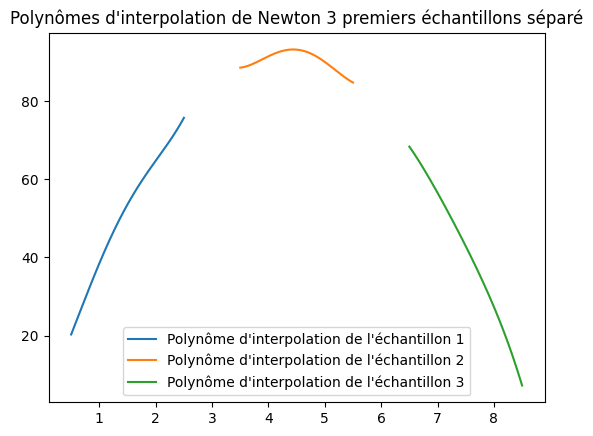

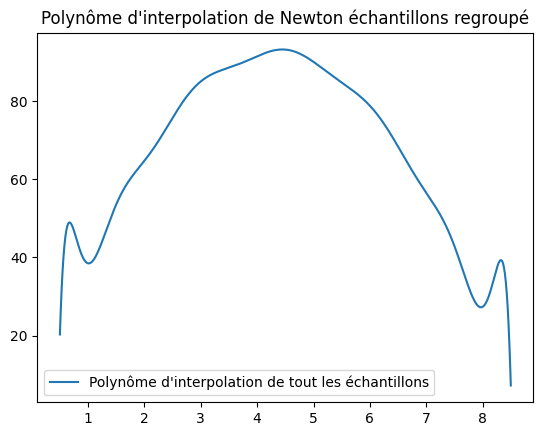

In [91]:
#---------- Tracé des polynômes d'interpolation :
X1 = np.linspace(0.5, 2.5, 1000) # On génère 1000 points entre 0.5 et 2.5
Y1 = [Eval(x, P1) for x in X1] # On évalue le polynôme d'interpolation de l'échantillon 1 sur ces points

X2 = np.linspace(3.5, 5.5, 1000) # On génère 1000 points entre 3.5 et 5.5
Y2 = [Eval(x, P2) for x in X2] # On évalue le polynôme d'interpolation de l'échantillon 2 sur ces points

X3 = np.linspace(6.5, 8.5, 1000) # On génère 1000 points entre 6.5 et 8.5
Y3 = [Eval(x, P3) for x in X3] # On évalue le polynôme d'interpolation de l'échantillon 3 sur ces point

X4 = np.linspace(0.5, 8.5, 1000) # On génère 1000 points entre 0.5 et 8.5
Y4 = [Eval(x, P4) for x in X4] # On évalue le polynôme d'interpolation de tout les échantillons sur ces points

plt.title("Polynômes d'interpolation de Newton 3 premiers échantillons séparé") # On donne un titre au graphique
plt.plot(X1, Y1, label="Polynôme d'interpolation de l'échantillon 1") # On trace le polynôme d'interpolation de l'échantillon 1
plt.plot(X2, Y2, label="Polynôme d'interpolation de l'échantillon 2") # On trace le polynôme d'interpolation de l'échantillon 2
plt.plot(X3, Y3, label="Polynôme d'interpolation de l'échantillon 3") # On trace le polynôme d'interpolation de l'échantillon 3
plt.legend() # On affiche la légende
plt.show() # On affiche le graphique

plt.title("Polynôme d'interpolation de Newton échantillons regroupé") # On donne un titre au graphique
plt.plot(X4, Y4, label="Polynôme d'interpolation de tout les échantillons") # On trace le polynôme d'interpolation de tout les échantillons
plt.legend() # On affiche la légende
plt.show() # On affiche le graphique


**2) Grâce a son oeil expert l'étudiant arrive a percevoir la vitesse et l'accélération de l'avion sur des points déjà connue.**   

* Voici les résulats qu'il a obtenus :

| X | 1 | 3 | 8 |
| -------- | -------- | -------- | -------- |
| y'(X)    | 15,375     | 2,302     | -58,483     |

<br>

| X | 1.5 | 3.5 | 7.5 |
| -------- | -------- | -------- | -------- |
| y''(X)    | -18,069     | 7,335    | 58,307     |

a. Dérivé le dernier polynome d'interpolation que vous avez calculez et vérifié l'erreur de la vitesse sur les nouveaux points connus. Qu'en dite vous ?  

b. Dérivié une nouvelle fois le polynome et faite de même pour l'acceleration. Qu'en dite vous ?  

c. Trouver le polynome d'interpolation généraliser en combinant les échantillons précédents aux nouveaux échantillons.

d. Admettons que l'on ne pouvais pas récupérer la vitesse et l'accélération en certain point de la courbe, diriez vous que l'interpolation aurait quand même pue être efficace pour déterminer ces derniers ? 

**3) Voici la fonction représentative de la hauteur de l'avion en papier en fonction du temps : $$y(t) = -\frac{1}{2}gt^2 + \sin(a)vt + h + \sin(t^2)$$**  

Avec :
* g = 9.81 La constante gravitationnel
* v = 50  La vitesse initiale
* a = 45  L'angle de lancé de base en degré
* h = 0  La hauteur initiale

a. Calculer les points de tchebychevs pour P = 10, 20, 30.

In [71]:
import math
import matplotlib.pyplot as plt
import numpy as np

def y(t):
    """ 
    Temps de vol avec 
    g = 9.81 # Constante gravitationnel
    v = 50 # Vitesse initiale
    a = 45 # Angle de lancé de base en degré
    h = 0 # Hauteur initiale
    = 8.67383817058 secondes
    """

    g = 9.81 # Constante gravitationnel
    v = 50 # Vitesse initiale
    a = 45 # Angle de lancé de base en degré
    h = 0 # Hauteur initiale

    return -(1/2)*g*t*t + math.sin(a)*v*t + h + math.sin(t*t)

def Tchebyschev(a, b, N):
    """
    retourne les N points de Tchebychev entre a et b
    Parameters

    a: float
        le bord gauche de l'intervalle
    b: float
        le bord droit de l'intervalle
    N: int
        le nombre de points
    """
    i = np.arange(N, 0, -1)
    return .5*(a+b) + .5*(b-a)*np.cos((2*i-1)/(2*N)*np.pi)

b. Réinterpoler la fonction a l'aide des points de tchebychevs.

c. Représenter graphiquement la première interpolation avec tout les échantillons, la dernière interpolation avec les points de tchebychevs et la fonction représentative de la hauteur de l'avion en papier en fonction du temp. Puis commenter les résultats.

**4) Conclure que pensez vous de l'interpolation pour résoudre ce problème ?**